<a href="https://colab.research.google.com/github/isa-ulisboa/greends-pml/blob/main/notebooks/T3_cotton_crop_problem_grid_search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Get data from https://www.kaggle.com/datasets/zohasohail/soil-detection-for-cotton-crop

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zohasohail/soil-detection-for-cotton-crop")

print("Path to dataset files:", path)

100%|██████████| 12.0k/12.0k [00:00<00:00, 15.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/zohasohail/soil-detection-for-cotton-crop/versions/3


In [3]:
import os
import pandas as pd

# List files in the downloaded path
file_list = os.listdir(path)
print("Files in the dataset directory:", file_list)

# Assuming there is an Excel file
excel_file = None
for f in file_list:
    if f.endswith('.xlsx'):
        excel_file = f
        break

if excel_file:
    excel_path = os.path.join(path, excel_file)
    print(f"Reading Excel file: {excel_path}")
    df = pd.read_excel(excel_path)
    print("Successfully loaded data into a DataFrame.")
    display(df.head())
else:
    print("No Excel file found in the directory.")

Files in the dataset directory: ['Detection of Soil for cotton crop.xlsx']
Reading Excel file: /root/.cache/kagglehub/datasets/zohasohail/soil-detection-for-cotton-crop/versions/3/Detection of Soil for cotton crop.xlsx
Successfully loaded data into a DataFrame.


,Sample ID,ph,Temperature,Humidity,Density,Electrical Conductivity,N,P,K,Ca,Mg,Grain Surface,Particle Attached,Particle Spacing,Particle Width,Cotton Crop
0,1,6.502985,20.879744,82.002744,0.92,7.40,100,50,43,30.00,19.00,smooth,no,close,narrow,0
1,2,7.038096,21.770462,80.319644,1.04,1.35,85,58,41,12.25,5.15,smooth,no,close,broad,0
2,3,7.840207,23.004459,72.320763,1.35,6.41,120,55,44,33.02,15.68,gritty,no,crowded,broad,1
3,4,6.980401,26.491096,80.158363,1.10,1.64,74,35,40,11.92,7.88,scaly,no,close,broad,0
4,5,7.628473,20.130175,71.604873,1.32,6.85,98,42,42,44.17,18.12,gritty,no,crowded,broad,1


# Organize data

Identify target variable and predictors

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify target variable
y = df['Cotton Crop']
X = df[['ph', 'Temperature', 'Humidity', 'Density', 'Electrical Conductivity', 'N', 'P', 'K']]


# Preprocessing

1) Define train and validation data subsets.

2) Convert all categorical predictors to numeric with a one-hot-encoder (which is required for `sklearn.tree.DecisionTreeClassifier`)



In [65]:
from sklearn.model_selection import train_test_split

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")

Training set shape: (38, 8)
Validation set shape: (10, 8)


# Grid search

1) Hyper-parameters search using the validation set

2) Set the full pipeline: preprocessing+classification

3) Predict for X_val and compare with actual y_val labels to compute accuracy

4) The best hyper-parameter value are the ones that lead to the best estimated accuracy

In [66]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

# Define the parameter grid for the manual search
param_grid = {
    'max_depth': [None, 5, 10, 15, 20, 25, 30],
    'min_samples_leaf': [1, 2, 4, 6, 8, 10, 15, 20]
}

best_score = -1
best_params = {}
best_dt_model = None # This will now store the DecisionTreeClassifier directly

print("Starting hyperparameter search using validation set...")

# Manually iterate through the parameter grid
for max_depth_val in param_grid['max_depth']:
    for min_samples_leaf_val in param_grid['min_samples_leaf']:

        # Create a Decision Tree Classifier with the current hyperparameters
        current_dt_classifier = DecisionTreeClassifier(
            random_state=42,
            max_depth=max_depth_val,
            min_samples_leaf=min_samples_leaf_val
        )

        # Fit the classifier on the training data
        current_dt_classifier.fit(X_train, y_train)

        # Make predictions on the validation set
        y_pred_val = current_dt_classifier.predict(X_val)

        # Evaluate accuracy on the validation set
        current_accuracy = accuracy_score(y_val, y_pred_val)

        # hyper-parameter values and estimated accuracy
        print(f"  Testing max_depth={max_depth_val}, min_samples_leaf={min_samples_leaf_val}, accuracy={current_accuracy:.4f}")


        # Check if this combination is better
        if current_accuracy > best_score:
            best_score = current_accuracy
            best_params = {'max_depth': max_depth_val,
                           'min_samples_leaf': min_samples_leaf_val}
            best_dt_model = current_dt_classifier # Store the best classifier found so far

print(f"\nBest hyperparameters found using validation set: {best_params}")
print(f"Best accuracy on the validation set: {best_score:.4f}")

Starting hyperparameter search using validation set...
  Testing max_depth=None, min_samples_leaf=1, accuracy=0.9000
  Testing max_depth=None, min_samples_leaf=2, accuracy=0.9000
  Testing max_depth=None, min_samples_leaf=4, accuracy=0.7000
  Testing max_depth=None, min_samples_leaf=6, accuracy=0.9000
  Testing max_depth=None, min_samples_leaf=8, accuracy=0.9000
  Testing max_depth=None, min_samples_leaf=10, accuracy=0.9000
  Testing max_depth=None, min_samples_leaf=15, accuracy=0.9000
  Testing max_depth=None, min_samples_leaf=20, accuracy=0.7000
  Testing max_depth=5, min_samples_leaf=1, accuracy=0.9000
  Testing max_depth=5, min_samples_leaf=2, accuracy=0.9000
  Testing max_depth=5, min_samples_leaf=4, accuracy=0.7000
  Testing max_depth=5, min_samples_leaf=6, accuracy=0.9000
  Testing max_depth=5, min_samples_leaf=8, accuracy=0.9000
  Testing max_depth=5, min_samples_leaf=10, accuracy=0.9000
  Testing max_depth=5, min_samples_leaf=15, accuracy=0.9000
  Testing max_depth=5, min_samp

# Visualize the best model

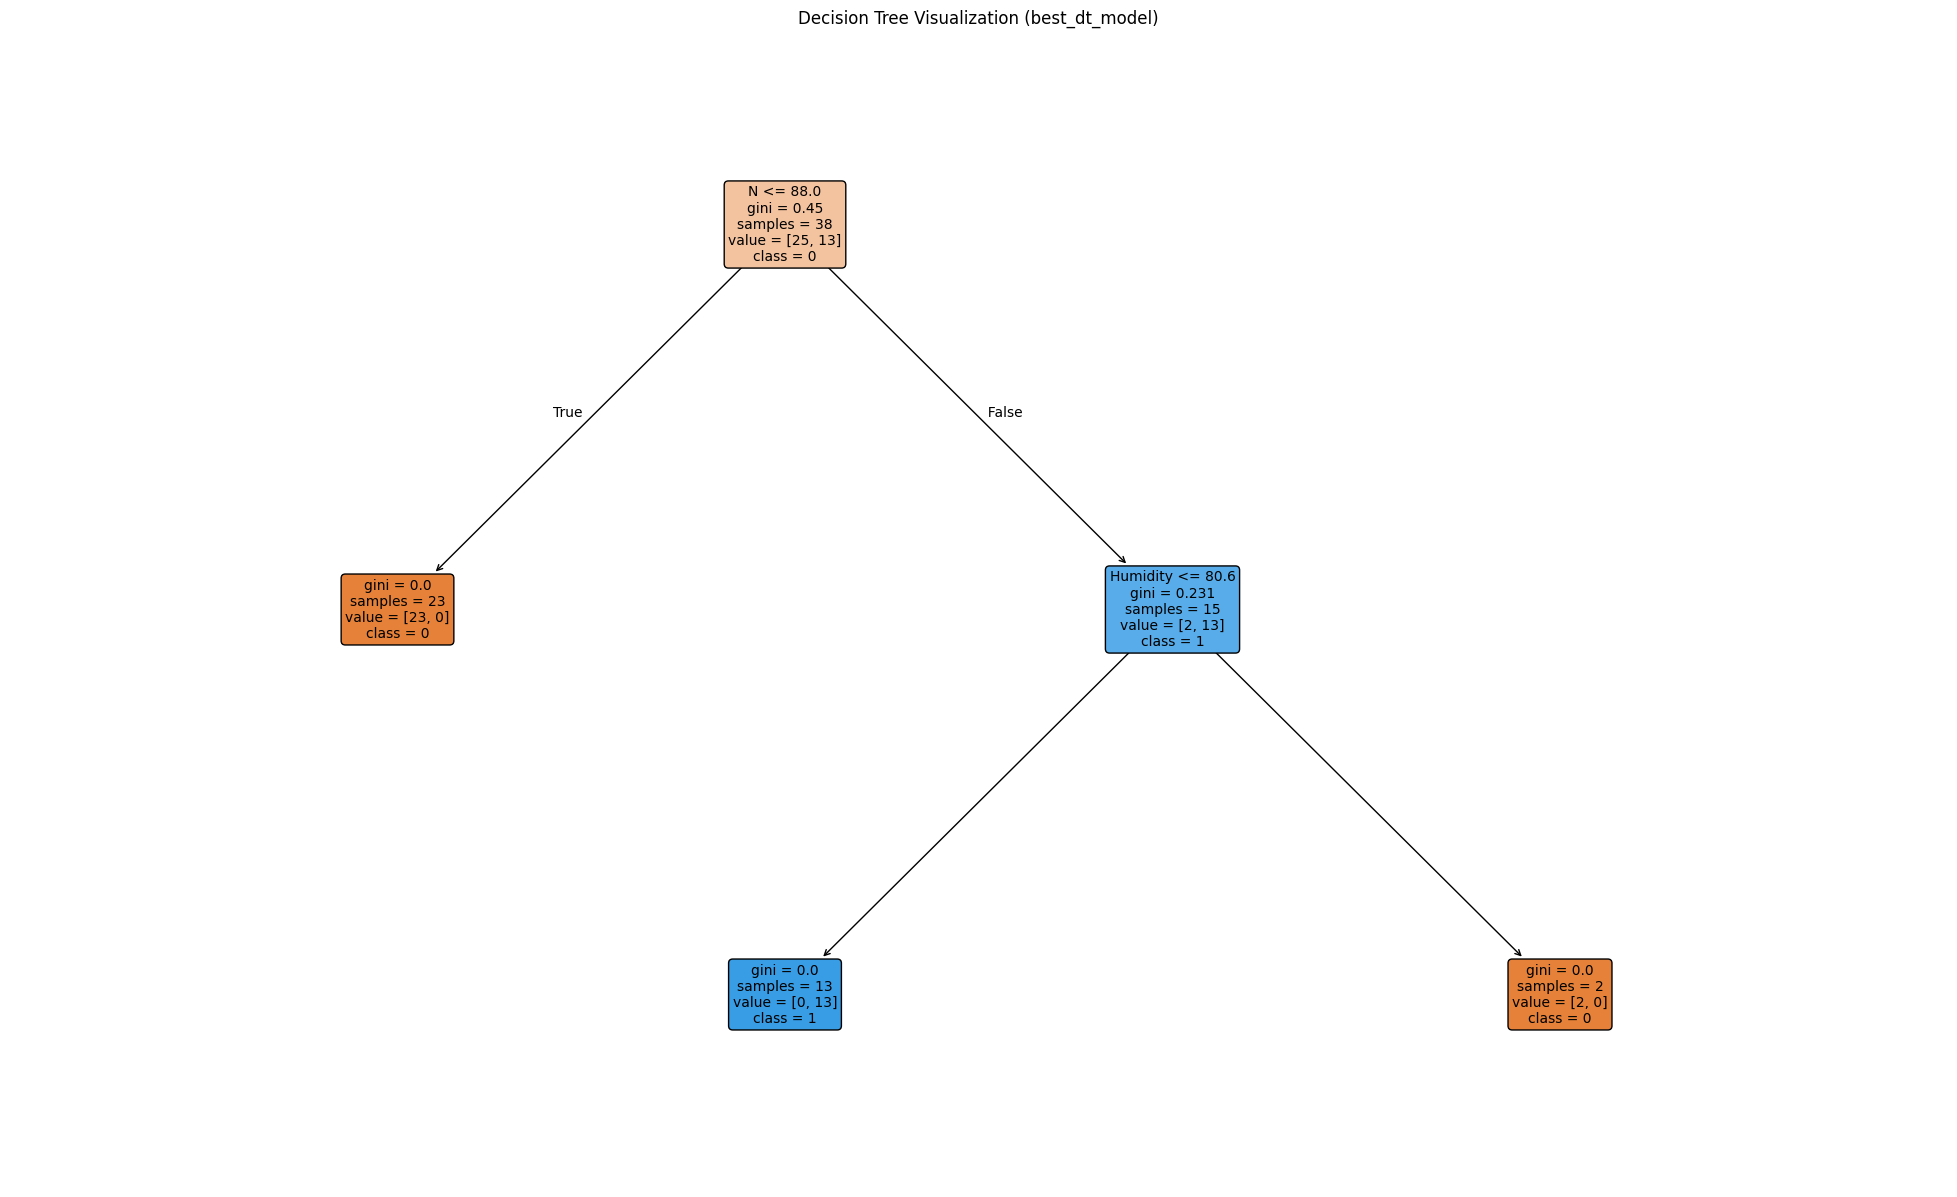

In [67]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# The best_dt_model is already the DecisionTreeClassifier
decision_tree_classifier = best_dt_model

# Get feature names: now only numerical features remain
all_feature_names = list(X.columns)

# Get class names (target variable unique values)
class_names = [str(c) for c in decision_tree_classifier.classes_]

plt.figure(figsize=(25, 15))
plot_tree(decision_tree_classifier,
          feature_names=all_feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Visualization (best_dt_model)")
plt.show()